In [1]:
import pandas as pd
import numpy as np

In [2]:
from sklearn.datasets import load_wine

In [6]:
wine = load_wine()

In [7]:
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target

In [11]:
df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


In [12]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

In [14]:
X_test , X_train , y_test , y_train = train_test_split(df.drop('target', axis=1), df['target'], test_size=0.2)

In [15]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [16]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

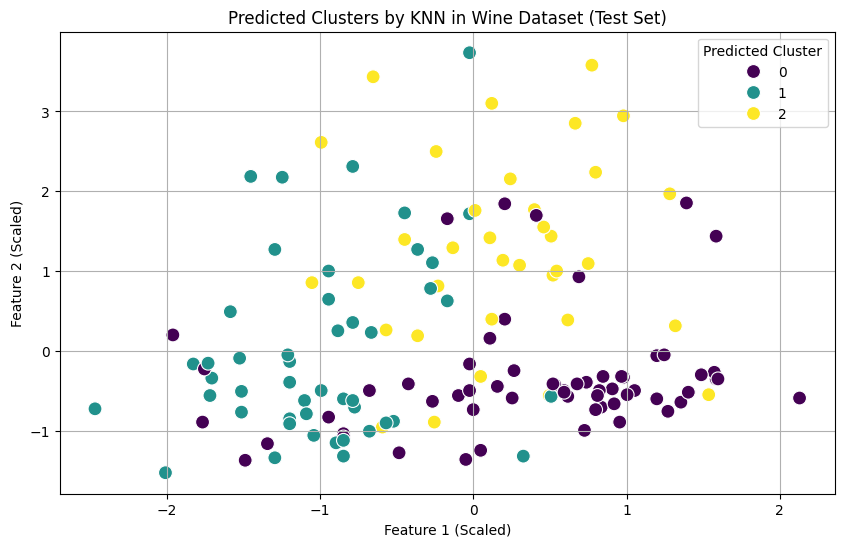

In [20]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test[:, 0], y=X_test[:, 1], hue=knn.predict(X_test), palette='viridis', s=100)
plt.title('Predicted Clusters by KNN in Wine Dataset (Test Set)')
plt.xlabel('Feature 1 (Scaled)')
plt.ylabel('Feature 2 (Scaled)')
plt.legend(title='Predicted Cluster')
plt.grid(True)
plt.show()

In [17]:
print(classification_report(y_test, knn.predict(X_test)))

              precision    recall  f1-score   support

           0       0.75      1.00      0.86        45
           1       0.91      0.74      0.82        58
           2       1.00      0.90      0.95        39

    accuracy                           0.87       142
   macro avg       0.89      0.88      0.87       142
weighted avg       0.89      0.87      0.87       142



### Elbow Method for K-Nearest Neighbors (KNN)

To find an optimal value for `n_neighbors` (k) in KNN, we can plot the error rate for different `k` values. An 'elbow' in this plot suggests a good balance between bias and variance.

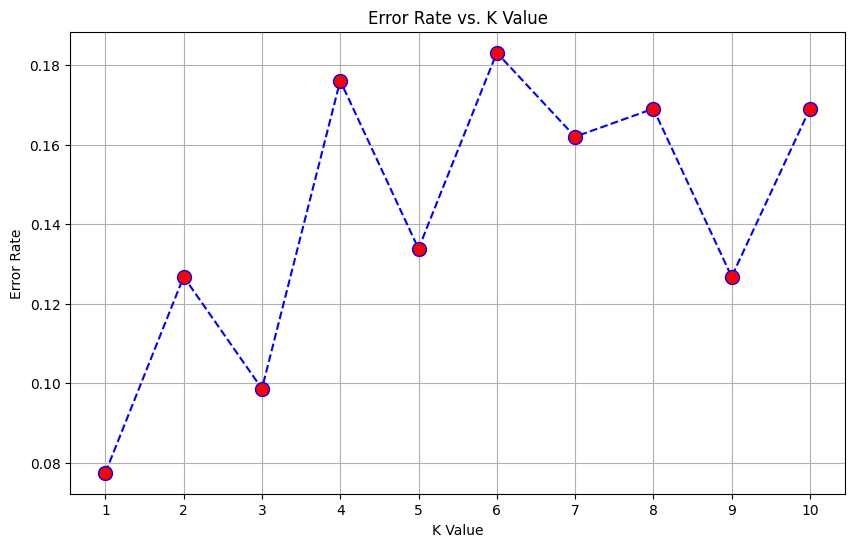

In [21]:
error_rate = []

# Try different k values from 1 to 10
for i in range(1, 11):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_test)
    # Calculate error rate (1 - accuracy)
    error_rate.append(np.mean(pred_i != y_test))

plt.figure(figsize=(10,6))
plt.plot(range(1,11), error_rate, color='blue', linestyle='dashed', marker='o', markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

### Principal Component Analysis (PCA)

PCA is a dimensionality reduction technique. We will apply PCA to our scaled features to see if it improves model performance or provides better visualization of clusters.

In [22]:
from sklearn.decomposition import PCA

# Initialize PCA to reduce to 2 components for visualization, or to a number that captures significant variance
pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print(f'Original number of features: {X_train.shape[1]}')
print(f'Reduced number of features: {X_train_pca.shape[1]}')
print(f'Explained variance ratio of first two components: {pca.explained_variance_ratio_.sum():.2f}')

Original number of features: 13
Reduced number of features: 2
Explained variance ratio of first two components: 0.57


### KNN on PCA Transformed Data - Predicted Clusters

Now, let's train a KNN model on the PCA-transformed data and visualize the predicted clusters.

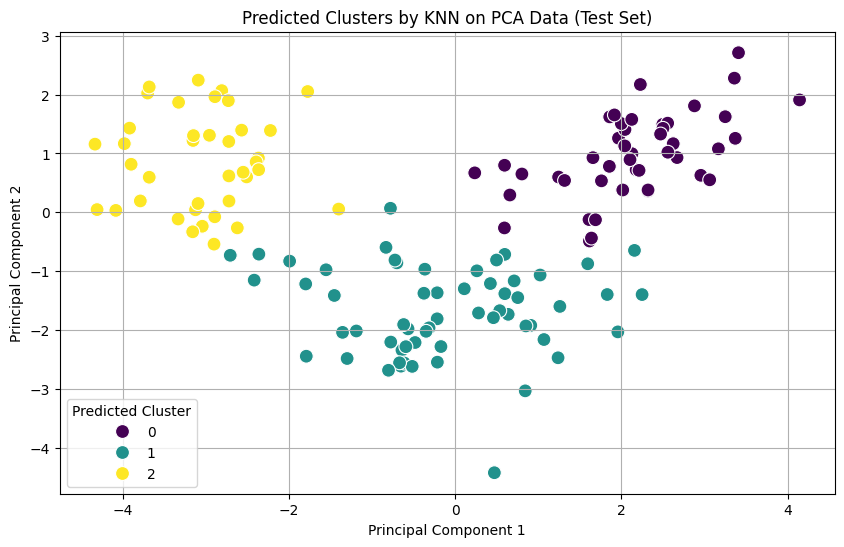

In [23]:
knn_pca = KNeighborsClassifier(n_neighbors=5)
knn_pca.fit(X_train_pca, y_train)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test_pca[:, 0], y=X_test_pca[:, 1], hue=knn_pca.predict(X_test_pca), palette='viridis', s=100)
plt.title('Predicted Clusters by KNN on PCA Data (Test Set)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Predicted Cluster')
plt.grid(True)
plt.show()

In [24]:
print('Classification Report for KNN on PCA Data (k=5):')
print(classification_report(y_test, knn_pca.predict(X_test_pca)))

Classification Report for KNN on PCA Data (k=5):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        45
           1       0.98      1.00      0.99        58
           2       1.00      0.97      0.99        39

    accuracy                           0.99       142
   macro avg       0.99      0.99      0.99       142
weighted avg       0.99      0.99      0.99       142



### Elbow Method for KNN with PCA Transformed Data

Let's re-run the elbow method to find an optimal 'k' value for KNN using the PCA-transformed data.

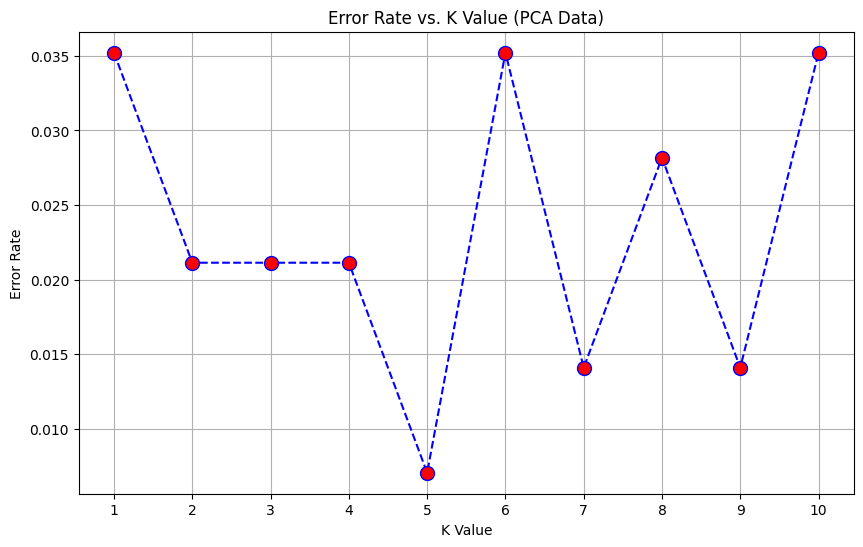

In [25]:
error_rate_pca = []

# Try different k values from 1 to 10 on PCA data
for i in range(1, 11):
    knn_pca_elbow = KNeighborsClassifier(n_neighbors=i)
    knn_pca_elbow.fit(X_train_pca, y_train)
    pred_i_pca = knn_pca_elbow.predict(X_test_pca)
    # Calculate error rate (1 - accuracy)
    error_rate_pca.append(np.mean(pred_i_pca != y_test))

plt.figure(figsize=(10,6))
plt.plot(range(1,11), error_rate_pca, color='blue', linestyle='dashed', marker='o', markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value (PCA Data)')
plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()